In [ ]:
# ─────────────────────────────────────────────
# PART 1: Install & Imports
# ─────────────────────────────────────────────
!pip install open3d plotly huggingface_hub scikit-image trimesh numpy scipy wandb -q

import open3d as o3d
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import math
import wandb
import os
import zipfile
from sklearn.decomposition import PCA
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.1 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# PART 2: Download & Extract Dataset
# ─────────────────────────────────────────────
zip_path = hf_hub_download(
    repo_id="BGLab/AgriField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="./data"
)

extract_dir = "./data/RawPCD_10k"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

ply_files = sorted([
    os.path.join(root, f)
    for root, _, files in os.walk(extract_dir)
    for f in files if f.endswith('.ply')
])

print(f"Total maize plants found: {len(ply_files)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Total maize plants found: 1045


In [ ]:
# ─────────────────────────────────────────────
# PART 3: Point Cloud → Mesh → Graph (Ball Pivoting + RAM-safe)
#
# KEEPS Ball Pivoting mesh conversion (triangle connectivity).
# IMPROVEMENT: stores sparse neighbour indices from the mesh
#              adjacency (~64 KB/sample) instead of dense [N,N]
#              matrices (~4 MB/sample). Dense adj built on-the-fly.
# ─────────────────────────────────────────────
NUM_VERTICES = 1024
K_STORE = 16   # max neighbours to store per vertex from mesh adj


def pcd_to_mesh(ply_path):
    """Load .ply point cloud and convert to triangle mesh via Ball Pivoting."""
    pcd = o3d.io.read_point_cloud(ply_path)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )
    distances = pcd.compute_nearest_neighbor_distance()
    avg_dist  = np.mean(distances)
    radius    = 3 * avg_dist

    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd,
        o3d.utility.DoubleVector([radius, radius * 2])
    )
    mesh.compute_vertex_normals()
    return mesh


def mesh_to_graph_sparse(ply_path, num_vertices=NUM_VERTICES, k_store=K_STORE):
    """
    Full pipeline: .ply → Ball Pivoting mesh → subsample vertices
                   → build adjacency from triangles → store as sparse KNN.

    Returns:
        vertices : [N, 3] float32 numpy
        knn_idx  : [N, K] int32 numpy (neighbours from mesh connectivity)
    """
    mesh      = pcd_to_mesh(ply_path)
    vertices  = np.asarray(mesh.vertices, dtype=np.float32)
    triangles = np.asarray(mesh.triangles)

    if len(vertices) == 0:
        return None, None

    # ── Subsample to fixed size ──────────────────────────────────
    N = len(vertices)
    if N >= num_vertices:
        idx = np.random.choice(N, num_vertices, replace=False)
    else:
        idx = np.random.choice(N, num_vertices, replace=True)

    # Map old vertex indices → new
    old_to_new = {old: new for new, old in enumerate(idx)}
    vertices   = vertices[idx]

    valid_tris = np.array([
        [old_to_new[v] for v in tri]
        for tri in triangles
        if all(v in old_to_new for v in tri)
    ]) if len(triangles) > 0 else np.empty((0, 3), dtype=int)

    # ── Normalise ────────────────────────────────────────────────
    vertices -= vertices.mean(axis=0)
    vertices /= (np.linalg.norm(vertices, axis=1).max() + 1e-8)

    # ── Build adjacency from mesh triangles ──────────────────────
    n = num_vertices
    adj = np.zeros((n, n), dtype=np.float32)
    np.fill_diagonal(adj, 1.0)

    for tri in valid_tris:
        a, b, c = int(tri[0]), int(tri[1]), int(tri[2])
        if max(a, b, c) >= n:
            continue
        adj[a, b] = adj[b, a] = 1.0
        adj[b, c] = adj[c, b] = 1.0
        adj[a, c] = adj[c, a] = 1.0

    # ── Convert to sparse: top-K neighbours per vertex ───────────
    # For vertices with fewer than K mesh neighbours, pad with self-loops
    knn_idx = np.zeros((n, k_store), dtype=np.int32)
    for i in range(n):
        neighbours = np.where(adj[i] > 0)[0]
        # Remove self-loop from neighbour list for sorting, add back later
        neighbours = neighbours[neighbours != i]
        if len(neighbours) >= k_store:
            # Take closest K by Euclidean distance
            dists = np.linalg.norm(vertices[neighbours] - vertices[i], axis=1)
            top_k = neighbours[np.argsort(dists)[:k_store]]
            knn_idx[i] = top_k
        else:
            # Pad with self-index
            knn_idx[i, :len(neighbours)] = neighbours
            knn_idx[i, len(neighbours):] = i

    return vertices.astype(np.float32), knn_idx.astype(np.int32)


def knn_to_dense_adj(knn_idx, num_vertices, device='cpu'):
    """
    Build normalised dense adjacency from stored mesh KNN indices.
    Called on-the-fly per batch.
    """
    N, K = knn_idx.shape
    adj = torch.zeros(N, N, device=device)

    rows = torch.arange(N, device=device).unsqueeze(1).expand(-1, K).reshape(-1)
    cols = knn_idx.reshape(-1).to(device)
    adj[rows, cols] = 1.0

    # Symmetrise + self-loops
    adj = torch.max(adj, adj.T)
    adj.fill_diagonal_(1.0)

    # Normalise: D^{-1/2} A D^{-1/2}
    deg = adj.sum(dim=1)
    d_inv = torch.where(deg > 0, 1.0 / deg.sqrt(), torch.zeros_like(deg))
    adj = d_inv.unsqueeze(1) * adj * d_inv.unsqueeze(0)

    return adj


In [ ]:
# ─────────────────────────────────────────────
# PART 4: PyTorch Dataset (Ball Pivoting mesh, RAM-safe)
# ─────────────────────────────────────────────

class MaizeMeshDataset(Dataset):
    def __init__(self, ply_files):
        self.vertices = []
        self.knn_idx  = []
        print(f"Processing {len(ply_files)} plants (Ball Pivoting)...")
        for i, path in enumerate(ply_files):
            try:
                v, k = mesh_to_graph_sparse(path)
                if v is not None:
                    self.vertices.append(v)
                    self.knn_idx.append(k)
            except Exception as e:
                print(f"  [skip] {os.path.basename(path)}: {e}")
            if (i + 1) % 50 == 0:
                print(f"  {i+1}/{len(ply_files)} done — {len(self.vertices)} valid")
        print(f"\nDataset ready: {len(self.vertices)} valid mesh graphs")

    def __len__(self):
        return len(self.vertices)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.vertices[idx], dtype=torch.float32),
            torch.tensor(self.knn_idx[idx],  dtype=torch.long)
        )


def collate_fn(batch):
    """Build dense adjacency on-the-fly from mesh KNN indices."""
    xs   = torch.stack([b[0] for b in batch])
    knns = [b[1] for b in batch]
    adjs = torch.stack([
        knn_to_dense_adj(knns[i], NUM_VERTICES)
        for i in range(len(knns))
    ])
    return xs, adjs


# Build dataset
full_dataset = MaizeMeshDataset(ply_files)

# Fixed split: first 500 train, rest val
TRAIN_SIZE = min(500, len(full_dataset))
train_set  = torch.utils.data.Subset(full_dataset, range(TRAIN_SIZE))
val_set    = torch.utils.data.Subset(full_dataset, range(TRAIN_SIZE, len(full_dataset)))

train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_set)} | Val: {len(val_set)}")


Processing 1045 plants (Ball Pivoting)...
  50/1045 done — 50 valid
  100/1045 done — 100 valid
  150/1045 done — 150 valid
  200/1045 done — 200 valid
  250/1045 done — 250 valid
  300/1045 done — 300 valid
  350/1045 done — 350 valid
  400/1045 done — 400 valid
  450/1045 done — 450 valid
  500/1045 done — 500 valid
  550/1045 done — 550 valid
  600/1045 done — 600 valid
  650/1045 done — 650 valid
  700/1045 done — 700 valid
  750/1045 done — 750 valid
  800/1045 done — 800 valid
  850/1045 done — 850 valid
  900/1045 done — 900 valid
  950/1045 done — 950 valid
  1000/1045 done — 1000 valid

Dataset ready: 1045 valid mesh graphs
Train: 500 | Val: 545


In [ ]:
# ─────────────────────────────────────────────
# PART 5: GCN Autoencoder — Improved
#
# IMPROVEMENTS:
#   - 5 GCN layers (was 3): wider receptive field on mesh
#   - Multi-scale pooling: max+mean from last + max from mid
#   - No BatchNorm in decoder (hurts point generation)
#   - Larger latent: 512 (was 256)
#   - Graph comes from MESH triangles (Ball Pivoting)
# ─────────────────────────────────────────────

class GCNLayer(nn.Module):
    """GCN layer: H\' = σ(A_hat · H · W) with BatchNorm."""
    def __init__(self, in_dim, out_dim, use_relu=True):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=False)
        self.bn = nn.BatchNorm1d(out_dim)
        self.use_relu = use_relu

    def forward(self, x, adj):
        x = self.linear(x)
        x = torch.bmm(adj, x)
        B, N, C = x.shape
        x = self.bn(x.reshape(B * N, C)).reshape(B, N, C)
        return F.relu(x) if self.use_relu else x


class GCNEncoder(nn.Module):
    """
    5-layer GCN with multi-scale pooling.
    3→64→128→256→256→512
    Pooling: max5(512) + mean5(512) + max3(256) = 1280 → 512
    """
    def __init__(self, in_dim=3, latent_dim=512):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, 64)
        self.gcn2 = GCNLayer(64, 128)
        self.gcn3 = GCNLayer(128, 256)
        self.gcn4 = GCNLayer(256, 256)
        self.gcn5 = GCNLayer(256, 512)

        self.fc = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

    def forward(self, x, adj):
        h1 = self.gcn1(x, adj)
        h2 = self.gcn2(h1, adj)
        h3 = self.gcn3(h2, adj)
        h4 = self.gcn4(h3, adj)
        h5 = self.gcn5(h4, adj)

        g = torch.cat([
            h5.max(dim=1)[0],
            h5.mean(dim=1),
            h3.max(dim=1)[0],
        ], dim=-1)
        return self.fc(g)


class MLPDecoder(nn.Module):
    """
    MLP decoder — NO BatchNorm.
    BatchNorm averages across plants in a batch,
    destroying per-plant shape diversity.
    """
    def __init__(self, latent_dim=512, num_points=NUM_VERTICES):
        super().__init__()
        self.num_points = num_points
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_points * 3)
        )

    def forward(self, z):
        return self.net(z).view(-1, self.num_points, 3)


class GCNAutoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = GCNEncoder(latent_dim=latent_dim)
        self.decoder = MLPDecoder(latent_dim=latent_dim)

    def forward(self, x, adj):
        z     = self.encoder(x, adj)
        recon = self.decoder(z)
        return recon, z


def chamfer_distance(pred, target):
    diff1 = pred.unsqueeze(2) - target.unsqueeze(1)
    dist1 = diff1.pow(2).sum(-1).min(dim=2)[0].mean()
    diff2 = target.unsqueeze(2) - pred.unsqueeze(1)
    dist2 = diff2.pow(2).sum(-1).min(dim=2)[0].mean()
    return dist1 + dist2


m = GCNAutoencoder(latent_dim=512).to(device)
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del m


Trainable parameters: 5,095,488


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Downloaded best_gcn_autoencoder.pt from W&B
Model loaded from checkpoint


wandb: Currently logged in as: ghosalsohom2003 (ghosalsohom2003-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Checkpoint val loss: 0.006069 (should be ~0.006213)
Epoch  150 | Train 0.001339 | Val 0.006301
Epoch  200 | Train 0.001086 | Val 0.006546


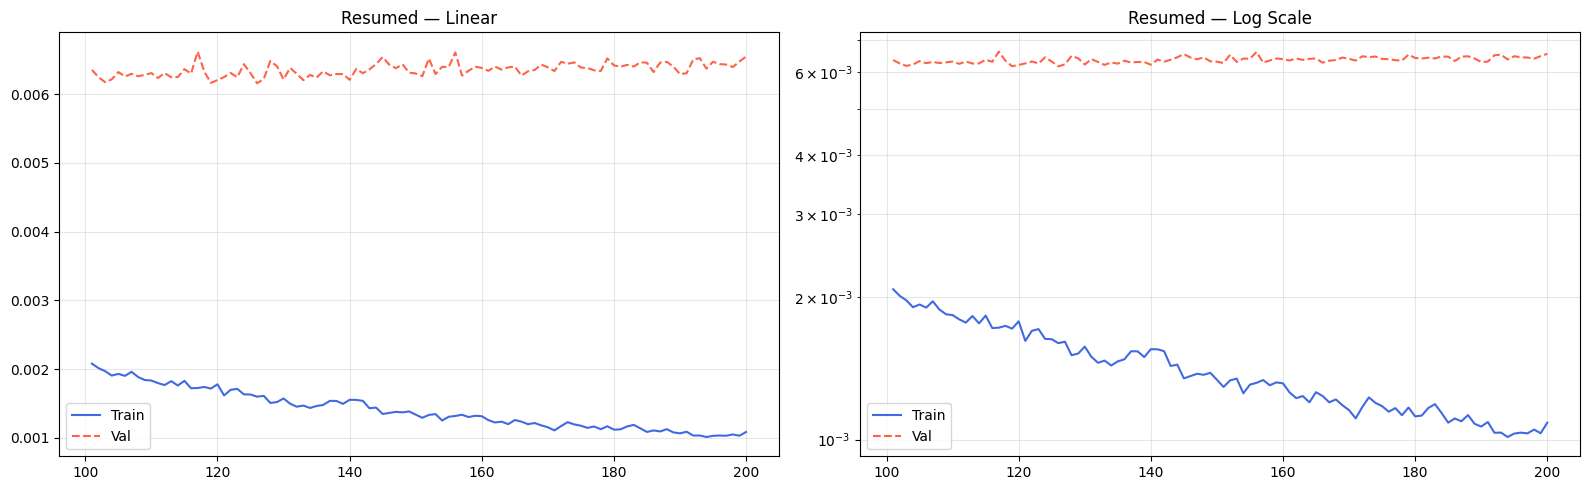

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▇▆▆▆▆▆▆▅▄▅▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁
train_loss_log,█▇▇▇▇▇▆▆▅▆▅▅▄▄▄▄▄▅▅▄▄▄▃▃▃▃▃▂▃▂▁▂▂▁▁▂▁▁▁▁
val_loss,▂▃▃▃▃█▄▁▃▅▁▅▂▂▂▄▃▄▅▇▃▅█▃▄▅▅▃▄▄▄▄▆▅▅▃▃▆▇▇
val_loss_log,▁▄▃▃▂█▂▃▂▁▂▄▃▂▃▃▄▅▇▅▃▅▃▅▄▅▃▄▄▅▅▄▅▅▄▃▆▄▅▇
epoch,200
lr,0.0001
train_loss,0.00109
train_loss_log,-2.964
val_loss,0.00655



Done. Best Val Loss: 0.006069


In [ ]:
# ─────────────────────────────────────────────
# RESUME Training from W&B Checkpoint
# ─────────────────────────────────────────────
import wandb
import math

# ── Step 1: Download checkpoint from W&B ──────────────────
# Find your run path on W&B: go to your run page → Overview → "Run path"
# It looks like: "ghosalsohom2003/maize-gcn-autoencoder/abc123xy"

WANDB_RUN_PATH = "ghosalsohom2003-own-use/maize-gcn-autoencoder/e2pt60a9"  # <-- UPDATE THIS
CHECKPOINT_NAME = "best_gcn_autoencoder.pt"

wandb.restore(CHECKPOINT_NAME, run_path=WANDB_RUN_PATH, root=".")
print(f"Downloaded {CHECKPOINT_NAME} from W&B")

# ── Step 2: Load model ───────────────────────────────────
CONFIG = dict(
    epochs     = 200,
    batch_size = 4,
    lr         = 1e-4,
    latent_dim = 512,
    num_points = NUM_VERTICES,
)

model     = GCNAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

model.load_state_dict(torch.load(CHECKPOINT_NAME, map_location=device))
print("Model loaded from checkpoint")

# ── Step 3: Resume W&B ───────────────────────────────────
wandb.init(
    project="maize-gcn-autoencoder",
    config=CONFIG,
    name="gcn-mesh-RESUMED-from-ep100",
    resume="allow"
)
wandb.watch(model, log="all", log_freq=20)

# ── Step 4: Verify checkpoint loaded correctly ───────────
model.eval()
check_loss = 0.0
n_check = 0
with torch.no_grad():
    for x, adj in val_loader:
        x, adj = x.to(device), adj.to(device)
        recon, _ = model(x, adj)
        check_loss += chamfer_distance(recon, x).item()
        n_check += 1
check_loss /= max(n_check, 1)
best_val_loss = check_loss
print(f"Checkpoint val loss: {check_loss:.6f} (should be ~0.006213)")

# ── Step 5: Continue training from epoch 101 ─────────────
START_EPOCH = 101
train_losses = []
val_losses   = []

for epoch in range(START_EPOCH, CONFIG["epochs"] + 1):

    model.train()
    train_loss = 0.0
    n_batches  = 0
    for x, adj in train_loader:
        x, adj = x.to(device), adj.to(device)
        optimizer.zero_grad()
        recon, _ = model(x, adj)
        loss = chamfer_distance(recon, x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        n_batches  += 1
    train_loss /= max(n_batches, 1)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    n_val    = 0
    with torch.no_grad():
        for x, adj in val_loader:
            x, adj = x.to(device), adj.to(device)
            recon, _ = model(x, adj)
            val_loss += chamfer_distance(recon, x).item()
            n_val    += 1
    val_loss /= max(n_val, 1)
    val_losses.append(val_loss)

    log_train = math.log10(train_loss) if train_loss > 0 else -10
    log_val   = math.log10(val_loss) if val_loss > 0 else -10
    wandb.log({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "train_loss_log": log_train, "val_loss_log": log_val, "lr": CONFIG["lr"],
    })

    if epoch % 50 == 0:
        model.eval()
        sample_x, sample_adj = next(iter(val_loader))
        sample_x   = sample_x[:1].to(device)
        sample_adj = sample_adj[:1].to(device)
        with torch.no_grad():
            sample_recon, _ = model(sample_x, sample_adj)
        orig_np  = sample_x[0].cpu().numpy()
        recon_np = sample_recon[0].cpu().numpy()
        wandb.log({
            "original_3d":      wandb.Object3D(np.hstack([orig_np,  np.tile([0,120,255], (len(orig_np),1))])),
            "reconstructed_3d": wandb.Object3D(np.hstack([recon_np, np.tile([255,80,0],  (len(recon_np),1))])),
        })
        print(f"Epoch {epoch:4d} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_gcn_autoencoder.pt")
        wandb.save("best_gcn_autoencoder.pt")

# ── Loss curves ───────────────────────────────────────────
epochs_x = list(range(START_EPOCH, START_EPOCH + len(train_losses)))

fig_mpl, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(epochs_x, train_losses, 'royalblue', lw=1.5, label='Train')
axes[0].plot(epochs_x, val_losses, 'tomato', lw=1.5, ls='--', label='Val')
axes[0].set_title("Resumed — Linear"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_x, train_losses, 'royalblue', lw=1.5, label='Train')
axes[1].plot(epochs_x, val_losses, 'tomato', lw=1.5, ls='--', label='Val')
axes[1].set_yscale('log')
axes[1].set_title("Resumed — Log Scale"); axes[1].legend(); axes[1].grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

fig_log = go.Figure()
fig_log.add_trace(go.Scatter(x=epochs_x, y=train_losses, mode='lines', name='Train', line=dict(color='royalblue', width=2)))
fig_log.add_trace(go.Scatter(x=epochs_x, y=val_losses, mode='lines', name='Val', line=dict(color='tomato', width=2, dash='dash')))
fig_log.update_layout(title="GCN Mesh — Resumed (Log Scale)", xaxis_title="Epoch",
    yaxis_title="Chamfer Distance", yaxis_type="log", template="plotly_dark")
fig_log.show()
wandb.log({"loss_curve_resumed_log": wandb.Plotly(fig_log)})

wandb.finish()
print(f"\nDone. Best Val Loss: {best_val_loss:.6f}")

In [ ]:
# # ─────────────────────────────────────────────
# # PART 6: Training
# #
# # IMPROVEMENTS (same philosophy as DGCNN 0.000369):
# #   - lr=1e-4 (was 1e-3): slower, precise convergence
# #   - No weight_decay, no scheduler, no grad clipping
# #   - 1000 epochs (was 100): patient training
# #   - Log-scale loss in both W&B and Colab
# # ─────────────────────────────────────────────
# CONFIG = dict(
#     epochs     = 200,
#     batch_size = 4,
#     lr         = 1e-4,
#     latent_dim = 512,
#     num_points = NUM_VERTICES,
#     graph_type = "Ball Pivoting mesh",
# )

# wandb.init(project="maize-gcn-autoencoder", config=CONFIG,
#            name="gcn-mesh-improved-lr1e4-1000ep")

# model     = GCNAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# wandb.watch(model, log="all", log_freq=20)

# best_val_loss  = float("inf")
# train_losses   = []
# val_losses     = []

# for epoch in range(1, CONFIG["epochs"] + 1):

#     # ── Train ──────────────────────────────────────────────────────
#     model.train()
#     train_loss = 0.0
#     n_batches  = 0
#     for x, adj in train_loader:
#         x, adj = x.to(device), adj.to(device)
#         optimizer.zero_grad()
#         recon, _ = model(x, adj)
#         loss = chamfer_distance(recon, x)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item()
#         n_batches  += 1
#     train_loss /= max(n_batches, 1)
#     train_losses.append(train_loss)

#     # ── Validate ───────────────────────────────────────────────────
#     model.eval()
#     val_loss = 0.0
#     n_val    = 0
#     with torch.no_grad():
#         for x, adj in val_loader:
#             x, adj = x.to(device), adj.to(device)
#             recon, _ = model(x, adj)
#             val_loss += chamfer_distance(recon, x).item()
#             n_val    += 1
#     val_loss /= max(n_val, 1)
#     val_losses.append(val_loss)

#     # ── W&B logging (log scale) ────────────────────────────────────
#     log_train = math.log10(train_loss) if train_loss > 0 else -10
#     log_val   = math.log10(val_loss) if val_loss > 0 else -10
#     wandb.log({
#         "epoch"          : epoch,
#         "train_loss"     : train_loss,
#         "val_loss"       : val_loss,
#         "train_loss_log" : log_train,
#         "val_loss_log"   : log_val,
#         "lr"             : CONFIG["lr"],
#     })

#     # Every 50 epochs — log 3D point clouds
#     if epoch % 50 == 0:
#         model.eval()
#         sample_x, sample_adj = next(iter(val_loader))
#         sample_x   = sample_x[:1].to(device)
#         sample_adj = sample_adj[:1].to(device)
#         with torch.no_grad():
#             sample_recon, _ = model(sample_x, sample_adj)
#         orig_np  = sample_x[0].cpu().numpy()
#         recon_np = sample_recon[0].cpu().numpy()
#         wandb.log({
#             "original_3d":      wandb.Object3D(np.hstack([orig_np,  np.tile([0,120,255], (len(orig_np),1))])),
#             "reconstructed_3d": wandb.Object3D(np.hstack([recon_np, np.tile([255,80,0],  (len(recon_np),1))])),
#         })

#     if epoch % 50 == 0:
#         print(f"Epoch {epoch:4d} | Train {train_loss:.6f} | Val {val_loss:.6f}")

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "best_gcn_autoencoder.pt")
#         wandb.save("best_gcn_autoencoder.pt")

# # ── Loss curves — LOG SCALE in both Colab and W&B ─────────────────────
# epochs_x = list(range(1, len(train_losses) + 1))

# # --- Colab: matplotlib ---
# fig_mpl, axes = plt.subplots(1, 2, figsize=(16, 5))

# axes[0].plot(epochs_x, train_losses, color='royalblue', linewidth=1.5, label='Train')
# axes[0].plot(epochs_x, val_losses,   color='tomato',    linewidth=1.5, label='Val', linestyle='--')
# axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Chamfer Distance")
# axes[0].set_title("Loss (Linear Scale)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# axes[1].plot(epochs_x, train_losses, color='royalblue', linewidth=1.5, label='Train')
# axes[1].plot(epochs_x, val_losses,   color='tomato',    linewidth=1.5, label='Val', linestyle='--')
# axes[1].set_yscale('log')
# axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Chamfer Distance (log)")
# axes[1].set_title("Loss (Log Scale)"); axes[1].legend(); axes[1].grid(True, alpha=0.3, which='both')

# plt.tight_layout(); plt.show()

# # --- W&B: Plotly log-scale ---
# fig_loss = go.Figure()
# fig_loss.add_trace(go.Scatter(x=epochs_x, y=train_losses, mode='lines',
#     name='Train', line=dict(color='royalblue', width=2)))
# fig_loss.add_trace(go.Scatter(x=epochs_x, y=val_losses, mode='lines',
#     name='Val', line=dict(color='tomato', width=2, dash='dash')))
# fig_loss.update_layout(
#     title="GCN Mesh AE — Loss (Log Scale)", xaxis_title="Epoch",
#     yaxis_title="Chamfer Distance", yaxis_type="log", template="plotly_dark")
# fig_loss.show()
# wandb.log({"loss_curve_log": wandb.Plotly(fig_loss)})

# # Linear version
# fig_lin = go.Figure()
# fig_lin.add_trace(go.Scatter(x=epochs_x, y=train_losses, mode='lines',
#     name='Train', line=dict(color='royalblue', width=2)))
# fig_lin.add_trace(go.Scatter(x=epochs_x, y=val_losses, mode='lines',
#     name='Val', line=dict(color='tomato', width=2, dash='dash')))
# fig_lin.update_layout(
#     title="GCN Mesh AE — Loss (Linear Scale)", xaxis_title="Epoch",
#     yaxis_title="Chamfer Distance", template="plotly_dark")
# wandb.log({"loss_curve_linear": wandb.Plotly(fig_lin)})

# wandb.finish()
# print(f"\nDone. Best Val Loss: {best_val_loss:.6f}")


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_loss_log,█▇▆▆▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_loss,█▅▃▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁▁▂▁▁▂▁▁▂▂
val_loss_log,█▇▆▆▄▄▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▂▁▁▂▂▁
epoch,152
lr,0.0001
train_loss,0.00138
train_loss_log,-2.85866
val_loss,0.00661


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch   50 | Train 0.003345 | Val 0.006213
Epoch  100 | Train 0.002102 | Val 0.006425


In [ ]:
import os
from google.colab import userdata
os.environ['WAND_API_KEY']=userdata.get('WAND_API_KEY')
import wandb

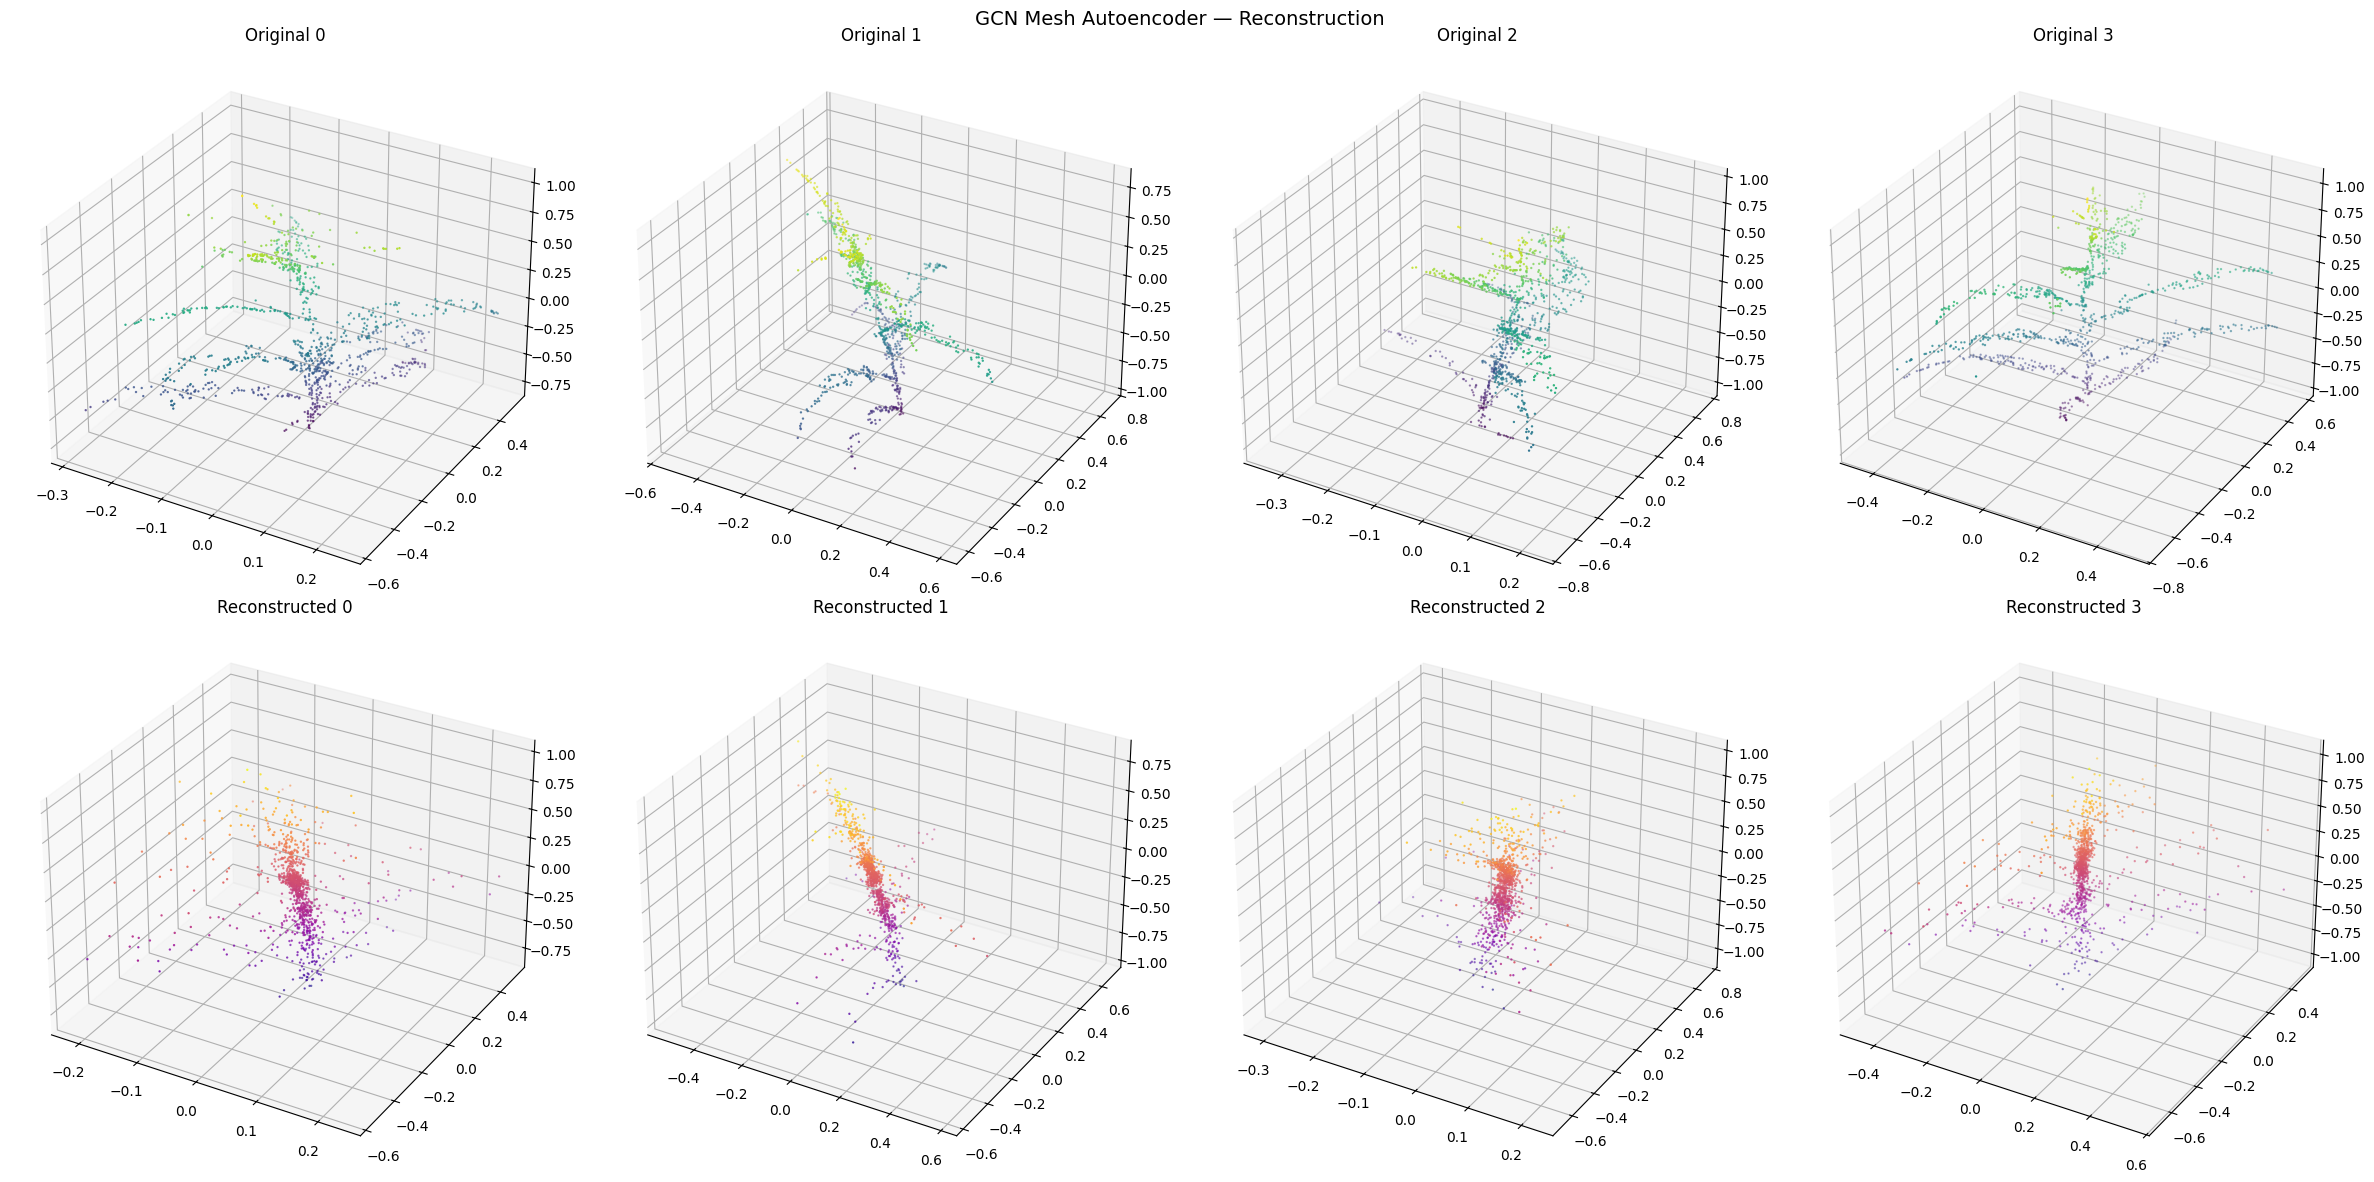

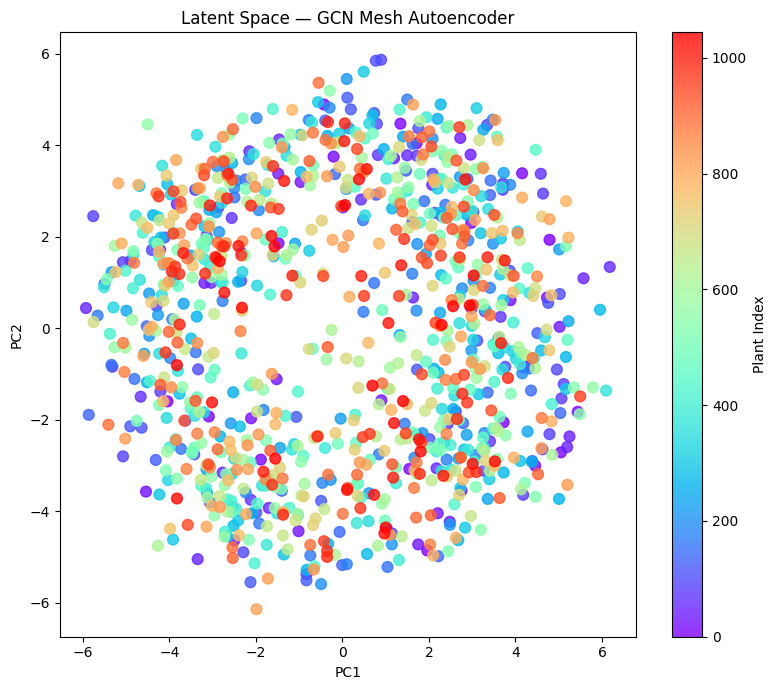

In [ ]:
# ─────────────────────────────────────────────
# PART 7: Visualise + PCA Latent Space
# ─────────────────────────────────────────────
model = GCNAutoencoder(latent_dim=512).to(device)
model.load_state_dict(torch.load("best_gcn_autoencoder.pt", map_location=device))
model.eval()

n_show = 4
fig = plt.figure(figsize=(6 * n_show, 12))

for i in range(n_show):
    verts_t, knn_t = full_dataset[i]
    sample_x   = verts_t.unsqueeze(0).to(device)
    sample_adj = knn_to_dense_adj(knn_t, NUM_VERTICES, device=device).unsqueeze(0)

    with torch.no_grad():
        recon, _ = model(sample_x, sample_adj)

    orig_np  = sample_x[0].cpu().numpy()
    recon_np = recon[0].cpu().numpy()

    ax = fig.add_subplot(2, n_show, i + 1, projection='3d')
    ax.scatter(orig_np[:,0], orig_np[:,1], orig_np[:,2],
               s=0.5, c=orig_np[:,2], cmap='viridis')
    ax.set_title(f"Original {i}")

    ax = fig.add_subplot(2, n_show, n_show + i + 1, projection='3d')
    ax.scatter(recon_np[:,0], recon_np[:,1], recon_np[:,2],
               s=0.5, c=recon_np[:,2], cmap='plasma')
    ax.set_title(f"Reconstructed {i}")

plt.suptitle("GCN Mesh Autoencoder — Reconstruction", fontsize=14)
plt.tight_layout()
wandb.init(project="maize-gcn-autoencoder", name="gcn-viz", resume="allow")
wandb.log({"reconstruction_plot": wandb.Image(fig)})
plt.show()

# ── PCA ────────────────────────────────────────────────────────────
latents = []
with torch.no_grad():
    for x, adj in DataLoader(full_dataset, batch_size=4, collate_fn=collate_fn):
        x, adj = x.to(device), adj.to(device)
        _, z = model(x, adj)
        latents.append(z.cpu().numpy())

latents   = np.concatenate(latents, axis=0)
latent_2d = PCA(n_components=2).fit_transform(latents)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(latent_2d[:,0], latent_2d[:,1],
                c=np.arange(len(latent_2d)), cmap='rainbow', s=60, alpha=0.8)
plt.colorbar(sc, label="Plant Index")
ax.set_title("Latent Space — GCN Mesh Autoencoder")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()

wandb.log({
    "latent_pca": wandb.Image(fig),
    "latent_table": wandb.Table(
        columns=["plant", "PC1", "PC2"],
        data=[[i, float(latent_2d[i,0]), float(latent_2d[i,1])]
              for i in range(len(latent_2d))]
    )
})
plt.show()
wandb.finish()
